In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel('/content/data1.xlsx')
df

FileNotFoundError: [Errno 2] No such file or directory: '/content/data1.xlsx'

In [ ]:
df.Category.isnull().sum() # getting all null values

np.int64(80)

In [ ]:
np.where(df.Category.isnull())

(array([  9,  11,  15,  32,  35,  38,  47,  48,  58,  59,  62,  64,  80,
         81,  82,  84,  95,  98, 122, 123, 140, 156, 161, 163, 164, 165,
        166, 167, 170, 174, 176, 177, 188, 192, 193, 212, 217, 223, 227,
        231, 237, 238, 246, 248, 250, 254, 257, 260, 267, 268, 269, 278,
        281, 287, 303, 328, 329, 333, 342, 345, 349, 357, 382, 384, 387,
        404, 406, 441, 445, 447, 451, 456, 459, 464, 471, 476, 477, 490,
        492, 494]),)

In [ ]:
80/df.shape[0] # to get approax percentage of missing values

0.16

In [ ]:
from collections import Counter

In [ ]:
Counter(df.Category).most_common()

[('B', 113), ('A', 112), ('C', 101), ('D', 94), (nan, 80)]

In [ ]:
#df.Category.fillna('B', inplace=True) # replacing values by 'B'

# OR

df.Category = df.Category.fillna('B') # assigniing values

In [ ]:
df.head(10)

,Category
0,C
1,D
2,C
3,A
4,B
5,A
6,B
7,C
8,D
9,B


In [ ]:
df.Category.isnull().sum() #to chheck

np.int64(80)

In [ ]:
df.Category.value_counts()

,count
Category,
A,136
B,126
C,124
D,114


In [ ]:
props = pd.DataFrame(df.Category.value_counts()) #to get converted into df
props

,count
Category,
B,113
A,112
C,101
D,94


In [ ]:
props['proportion'] = props['count']/sum(props['count']) # adding new column

In [ ]:
props

,count,proportion
Category,,
B,113,0.269048
A,112,0.266667
C,101,0.240476
D,94,0.223810


In [ ]:
from numpy import random

In [ ]:
random_values = np.random.choice(['A','B','C','D'],size=80,p=props.proportion) # generte random 80 values as A<B<C<D

In [ ]:
ind = np.where(df.Category.isnull()) #getting seperated null values

In [ ]:
df.loc[ind[0], 'Category'] = random_values # assigning those random values inplaceof null

In [ ]:
df.Category.isnull().sum() # to check

np.int64(0)

In [ ]:
# Any dATASEET given for eda first use .info command

In [ ]:
df1 = pd.read_excel('data2.xlsx')
df1.head()

,Category,Continuous_Value
0,C,-4008.098297
1,D,-3887.888132
2,NaN,-3712.188312
3,C,-3416.823821
4,D,-5845.073897


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category          850 non-null    object 
 1   Continuous_Value  880 non-null    float64
dtypes: float64(1), object(1)
memory usage: 15.8+ KB


In [ ]:
df1.Continuous_Value.isnull().sum() #to chheck

np.int64(120)

In [ ]:
df1.Continuous_Value = df1.Continuous_Value.fillna(df1.Continuous_Value.median())

In [ ]:
df1.Continuous_Value.isnull().sum() #to chheck

np.int64(120)

In [ ]:
# different types of graph

In [ ]:
import scipy
from scipy import stats
from scipy.stats import binom, poisson, norm, t
from scipy.stats import expon

In [ ]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

In [ ]:
states = ['KN', 'MH','AP','MP', 'UP']
counts = [40,35,50,20,15]

<BarContainer object of 5 artists>

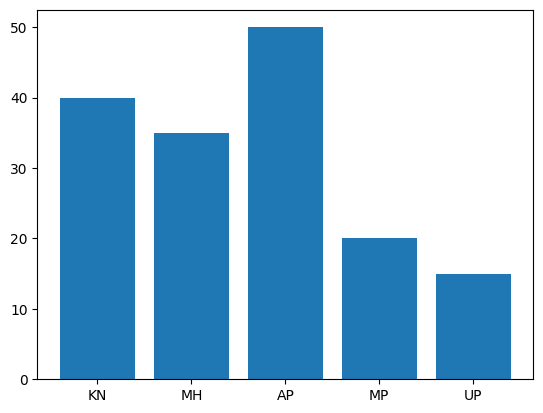

In [ ]:
plt.bar(states, counts)

In [ ]:
df = pd.read_excel("/content/CDAC_DataBook.xlsx", sheet_name='ERPData')
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


In [ ]:
df1 = df.MaterialID.value_counts()
df1

,count
MaterialID,
TMI-43T,15
AXCP-78,11
DDBN-89,8
SDRT-67,6
GCVB-79,5
LXCV-21,5


<BarContainer object of 6 artists>

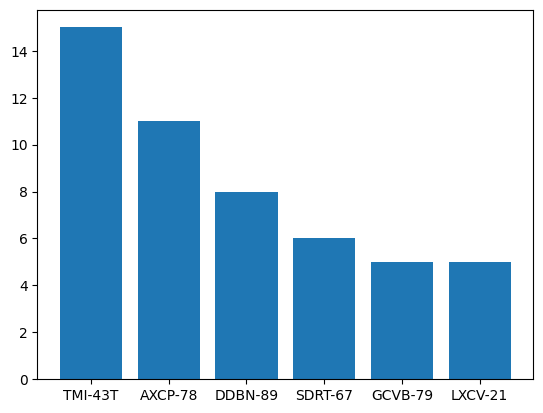

In [ ]:
df1 = df.MaterialID.value_counts()
plt.bar(df1.index, df1)

In [ ]:
grp1 = df.groupby('MaterialID')
grp1.groups

{'AXCP-78': [1, 3, 4, 24, 25, 37, 38, 39, 46, 47, 48], 'DDBN-89': [22, 23, 26, 30, 40, 43, 45, 49], 'GCVB-79': [8, 15, 34, 35, 36], 'LXCV-21': [2, 27, 28, 29, 44], 'SDRT-67': [10, 11, 16, 17, 41, 42], 'TMI-43T': [0, 5, 6, 7, 9, 12, 13, 14, 18, 19, 20, 21, 31, 32, 33]}

In [ ]:
df2 = grp1.Quantity.agg('sum')
df2

,Quantity
MaterialID,
AXCP-78,898
DDBN-89,383
GCVB-79,182
LXCV-21,243
SDRT-67,294
TMI-43T,885


<BarContainer object of 6 artists>

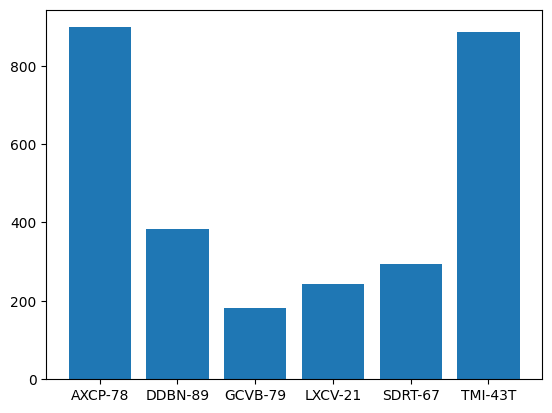

In [ ]:
plt.bar(df2.index, df2)

<BarContainer object of 6 artists>

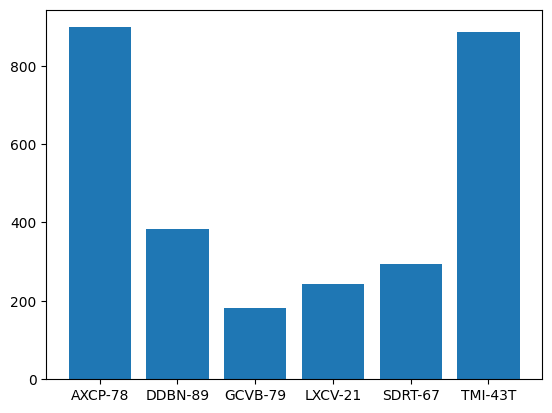

In [ ]:
grp1 = df.groupby('MaterialID')
df2 = grp1.Quantity.agg('sum')
plt.bar(df2.index,df2)  # bar chart for total

In [ ]:
df.head(5)

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


In [ ]:
# what are freq for each material id and combination
df1 = pd.crosstab(df.Location, df.MaterialID)
df1

MaterialID,AXCP-78,DDBN-89,GCVB-79,LXCV-21,SDRT-67,TMI-43T
Location,,,,,,
MWH-1,5,3,0,0,2,1
MWH-2,1,1,4,1,1,1
MWH-3,1,1,0,1,0,1
MWH-4,1,2,0,0,1,11
MWH-5,3,1,1,3,2,1


<Axes: xlabel='Location'>

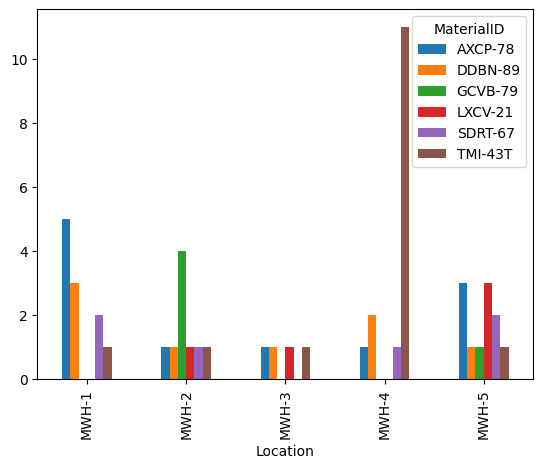

In [ ]:
df1.plot(kind='bar')

In [ ]:
df = pd.read_excel("/content/CDAC_DataBook.xlsx", sheet_name='nominal')
df.head()

,ses,write,math,prog
0,1,35,41,1
1,2,33,41,2
2,3,39,44,3
3,1,37,42,1
4,2,31,40,2


In [ ]:
df1 = pd.crosstab(df.ses, df.prog)
df1

prog,1,2,3
ses,,,
1,29,16,2
2,6,51,38
3,1,9,48


prog,1,2,3
ses,,,
1,29,16,2
2,6,51,38
3,1,9,48


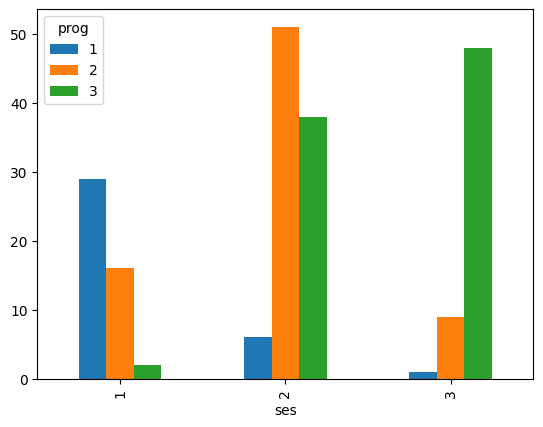

In [ ]:
df1.plot(kind='bar')
df1

In [ ]:
df = pd.read_excel("/content/CDAC_DataBook.xlsx", sheet_name='ERPData')
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


{'whiskers': [<matplotlib.lines.Line2D at 0x7cc09fd15100>,
 'caps': [<matplotlib.lines.Line2D at 0x7cc09fd15e20>,
 'boxes': [<matplotlib.lines.Line2D at 0x7cc09fd16930>],
 'medians': [<matplotlib.lines.Line2D at 0x7cc09fd16b40>],
 'fliers': [<matplotlib.lines.Line2D at 0x7cc09fd14c20>],
 'means': []}

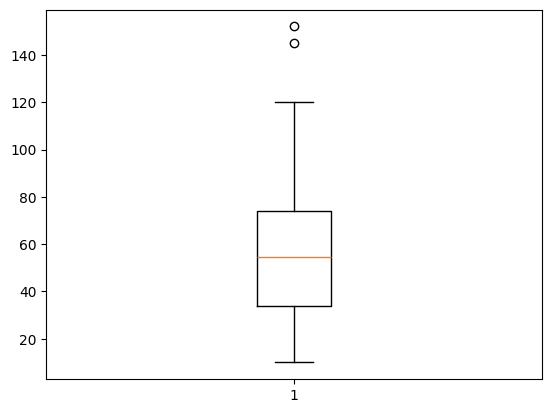

In [ ]:
plt.boxplot(df.Quantity)

{'whiskers': [<matplotlib.lines.Line2D at 0x7cc09fe92690>,
 'caps': [<matplotlib.lines.Line2D at 0x7cc09fe92c60>,
 'boxes': [<matplotlib.lines.Line2D at 0x7cc09fe923c0>,
 'medians': [<matplotlib.lines.Line2D at 0x7cc09fe93290>,
 'fliers': [<matplotlib.lines.Line2D at 0x7cc09fd05580>,
 'means': []}

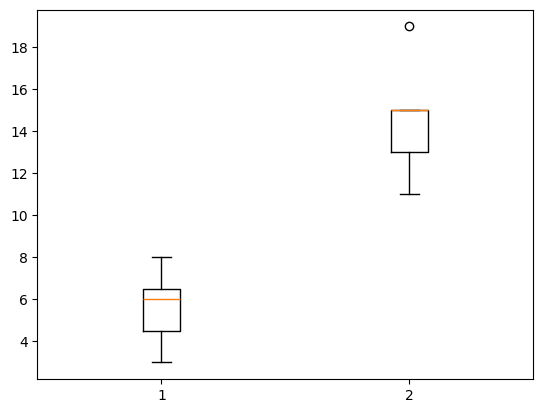

In [ ]:
male_sal = [4,6,5,3,7,6,8]
female_sal = [11,15,13,19,15]
plt.boxplot([male_sal, female_sal])

In [ ]:
df = pd.read_excel("/content/CDAC_DataBook.xlsx", sheet_name='ERPData')
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


/tmp/ipykernel_1838/828810707.py:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df1 = grp1.Quantity.agg(sum)


<Axes: xlabel='MaterialID'>

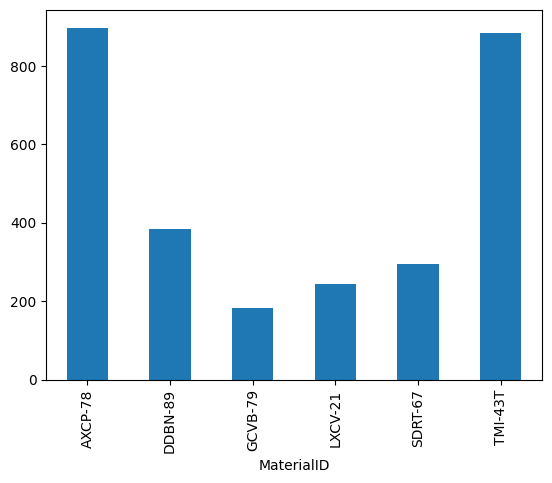

In [ ]:
#one method to plot total weight of each material ID
grp1 = df.groupby('MaterialID')
df1 = grp1.Quantity.agg(sum)
df1.plot(kind='bar')

<Axes: xlabel='MaterialID'>

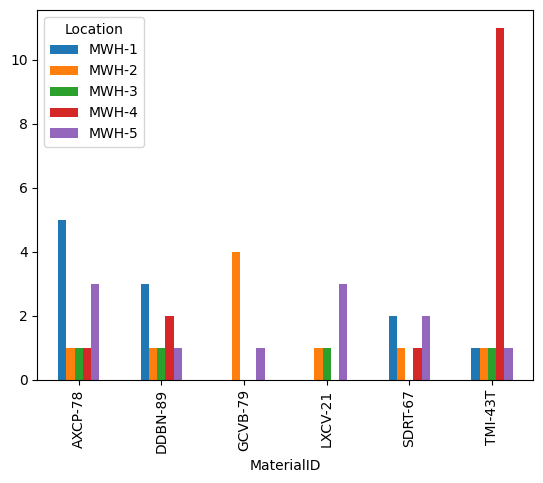

In [ ]:
df2 = pd.crosstab(df.MaterialID, df.Location) # giving freq
df2.plot(kind='bar')

<Axes: xlabel='MaterialID'>

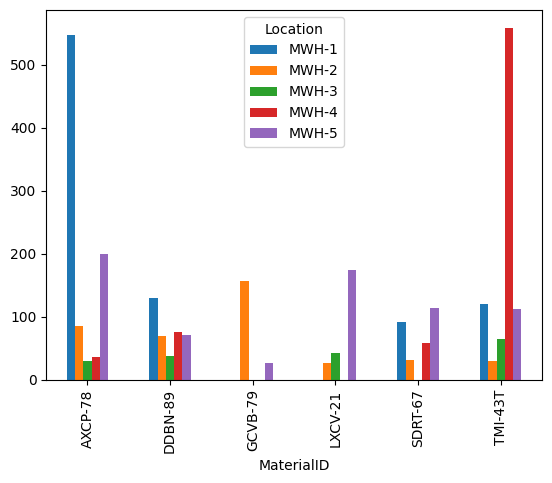

In [ ]:
df3 =  pd.crosstab(df.MaterialID, df.Location, values=df.Quantity, aggfunc='sum') # total of each material ID on each location
df3.plot(kind='bar')

<Axes: xlabel='MaterialID'>

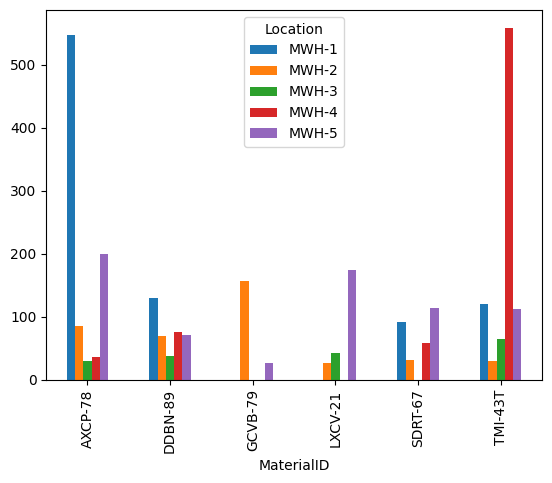

In [ ]:
# same using pivot table
df4 = df.pivot_table(values='Quantity', index='MaterialID',columns='Location', aggfunc='sum')
df4.plot(kind='bar')

In [ ]:
# scatter plot
df = pd.read_excel("/content/CDAC_DataBook.xlsx", sheet_name='faithful')
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


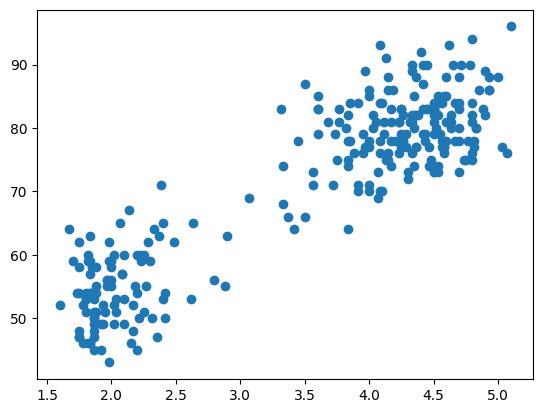

In [ ]:
plt.scatter(df.eruptions, df.waiting)

In [ ]:
min(df.eruptions)

1.6

In [ ]:
max(df.eruptions)

5.1

(array([ 63.,  41.,  61., 107.]),
 array([1.5, 2.1, 3.5, 4.2, 5.2]),
 <BarContainer object of 4 artists>)

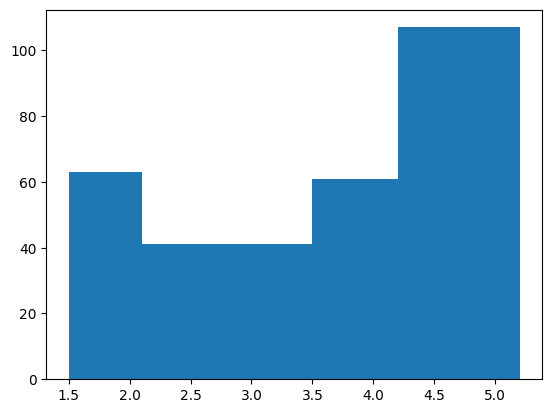

In [ ]:
cats = [1.5,2.1,3.5,4.2,5.2]
plt.hist(df.eruptions, cats)

(array([45., 36., 13.,  3.,  4., 12., 29., 52., 54., 24.]),
 array([1.6 , 1.95, 2.3 , 2.65, 3.  , 3.35, 3.7 , 4.05, 4.4 , 4.75, 5.1 ]),
 <BarContainer object of 10 artists>)

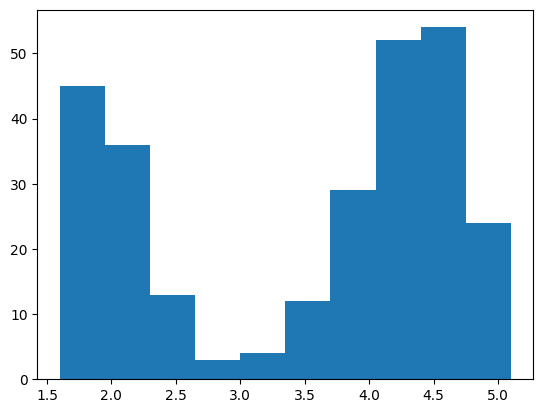

In [ ]:
plt.hist(df.eruptions)

In [ ]:
df1 = df.iloc[np.where(df.eruptions<=3.6)]
df2 = df.iloc[np.where(df.eruptions>=3.6)]


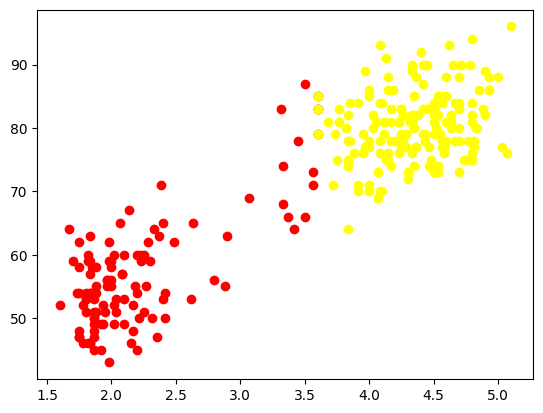

In [ ]:
plt.scatter(df1.eruptions,df1.waiting, c='red')
plt.scatter(df2.eruptions,df2.waiting, c='yellow')

In [ ]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
class_count=df['class'].value_counts()
plt.bar(class_counts.index, class_counts.values)

<Axes: xlabel='class', ylabel='count'>

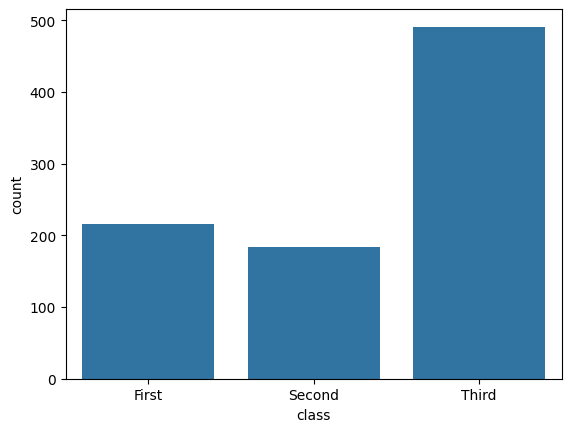

In [ ]:
df['class'].value_counts()
sns.countplot(x='class', data=df)

/tmp/ipykernel_1838/2285859452.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='class', y='fare', data=df, ci=None)


<Axes: xlabel='class', ylabel='fare'>

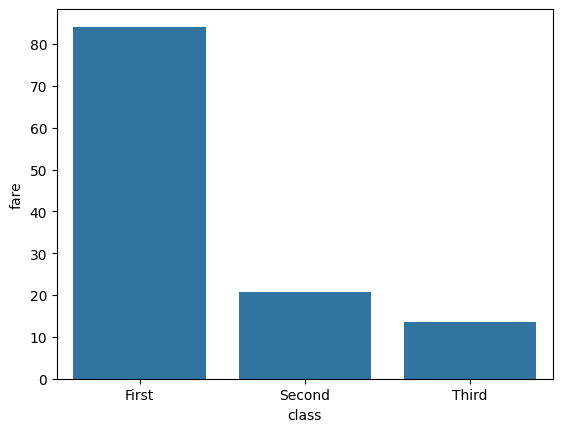

In [ ]:
sns.barplot(x='class', y='fare', data=df, ci=None)

<Axes: >

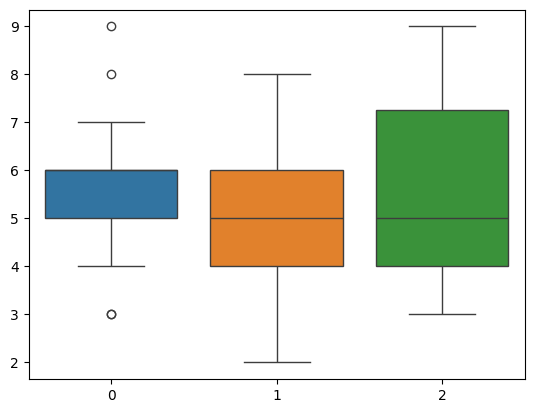

In [ ]:
x1= [5,6,4,3,5,6,7,8,9,6,6,3,6]
x2 = [3,5,4,5,6,7,6,5,4,5,6,7,8,2,3,5]
x3 = [4,5,3,4,5,7,8,9,4,3,6,8]

sns.boxplot(data=[x1,x2,x3])

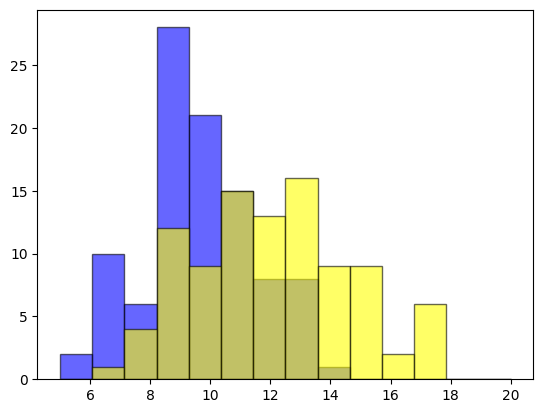

In [ ]:
group1 = np.random.normal(loc=10, scale=2, size=100)  # Volcano A mean is 10 and std dev=2
group2 = np.random.normal(loc=12, scale=2.5, size=100)  # e.g., Volcano B

bins = np.linspace(5, 20, 15)  # common bin edges for both groups

plt.hist(group1, bins=bins, alpha=0.6, label='Volcano A', color='blue', edgecolor='black')
plt.hist(group2, bins=bins, alpha=0.6, label='Volcano B', color='yellow', edgecolor='black')
plt.show()

In [ ]:
df = pd.read_excel('ManHours.xlsx')
df

,Name,Client,Hours,Grade,Team
0,A,CDAC,3,A,2
1,B,CDAC,4,A,2
2,A,Infy,2,B,1
3,C,Infy,4,C,3
4,A,CDAC,3,A,2
5,B,TCS,5,A,1
6,A,Infy,3,C,2
7,A,TCS,3,B,2
8,C,Infy,4,A,3
9,C,TCS,3,A,1


In [ ]:
df = pd.read_csv("/content/6-Churn_ModellingDataSet.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df = df.drop(['RowNumber','CustomerId','Surname'],axis=1)


In [ ]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


{'whiskers': [<matplotlib.lines.Line2D at 0x7fdd677d6750>,
 'caps': [<matplotlib.lines.Line2D at 0x7fdd677d6cf0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fdd677d64b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fdd677d7260>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fdd677d73b0>],
 'means': []}

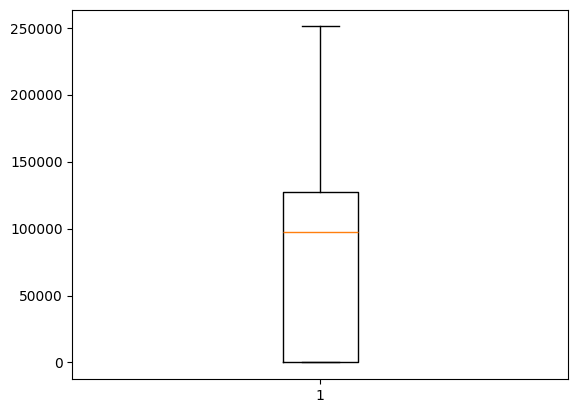

In [ ]:
plt.boxplot(df.Balance)

{'whiskers': [<matplotlib.lines.Line2D at 0x7fdd671dbbc0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fdd6719c170>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fdd671db8f0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fdd6719c7a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fdd6719ca40>],
 'means': []}

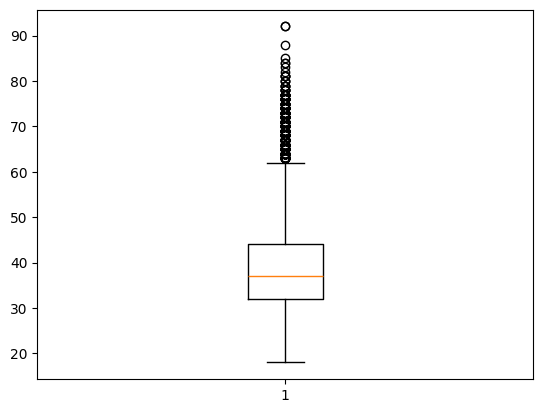

In [ ]:
plt.boxplot(df.Age) # not to remove outlier because age is normal

In [ ]:
exit_counts=df.Exited.value_counts()
exit_counts


,count
Exited,
0,7963
1,2037


{'whiskers': [<matplotlib.lines.Line2D at 0x7fdd66f6cbc0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fdd66f6d160>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fdd66f6c8f0>,
 'medians': [<matplotlib.lines.Line2D at 0x7fdd66f6d730>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fdd66f6d9d0>,
 'means': []}

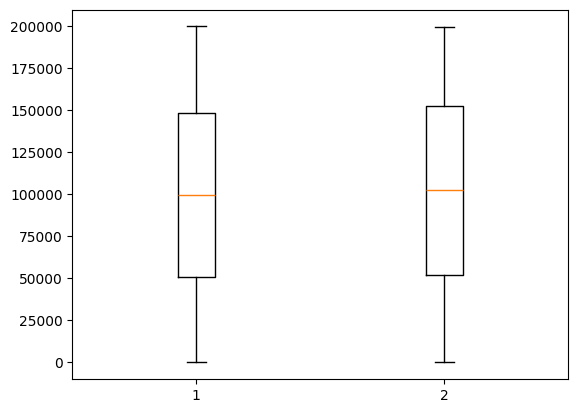

In [ ]:
df0 = df.iloc[np.where(df.Exited==0)]
df1 = df.iloc[np.where(df.Exited==1)]
plt.boxplot([df0.EstimatedSalary, df1.EstimatedSalary])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fdd6759f2f0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fdd6759e180>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fdd674886b0>,
 'medians': [<matplotlib.lines.Line2D at 0x7fdd6759c4a0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fdd6759fc20>,
 'means': []}

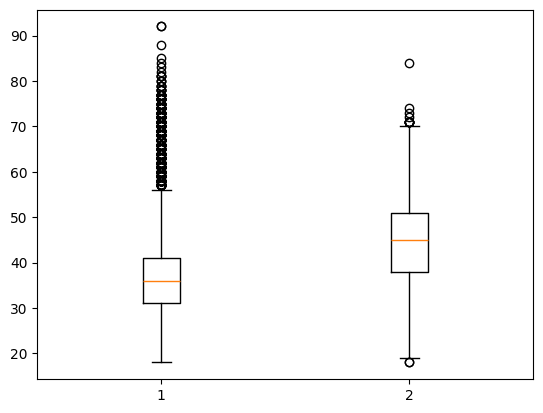

In [ ]:
plt.boxplot([df0.Age, df1.Age])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fdd66f299a0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fdd66f29fd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fdd66f29700>,
 'medians': [<matplotlib.lines.Line2D at 0x7fdd66f2a5d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fdd66f2a8d0>,
 'means': []}

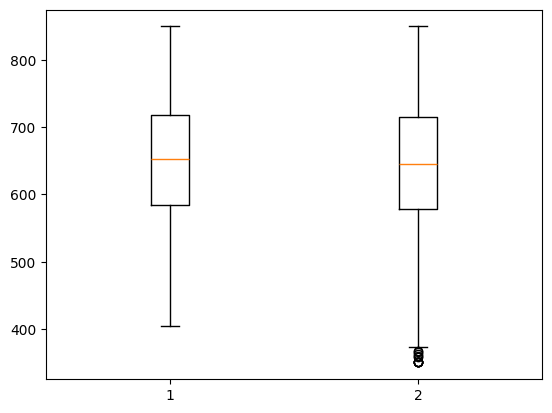

In [ ]:
plt.boxplot([df0.CreditScore, df1.CreditScore])

In [ ]:
df_400 = df.iloc[np.where(df.CreditScore<=400)]
exit_400 = df_400.Exited.value_counts()

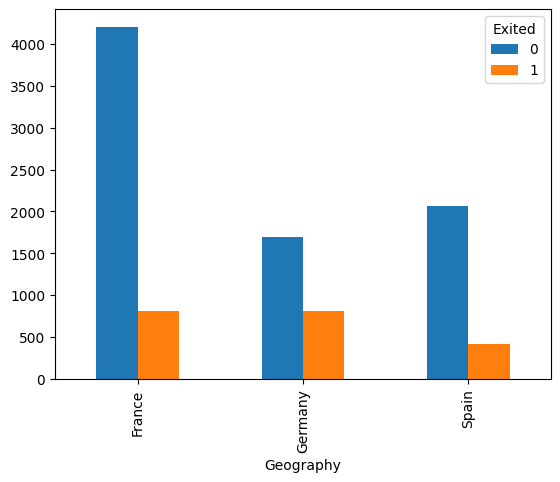

In [ ]:
geo = pd.crosstab(df.Geography, df.Exited)
geo.plot(kind='bar')
geo['prop'] = geo[1]/(geo[0]-geo[1])

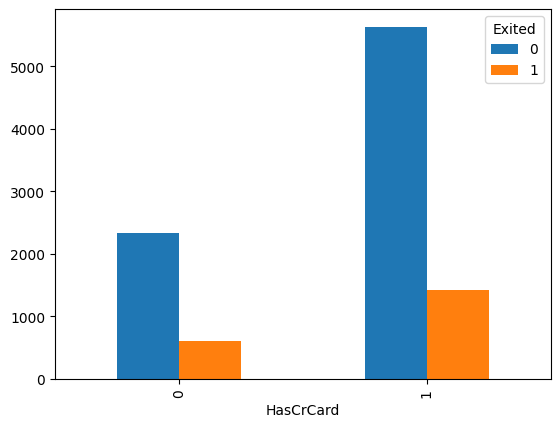

In [ ]:
cc = pd.crosstab(df.HasCrCard, df.Exited)
cc.plot(kind='bar')
cc['prop'] = cc[1]/(cc[0]-cc[1])

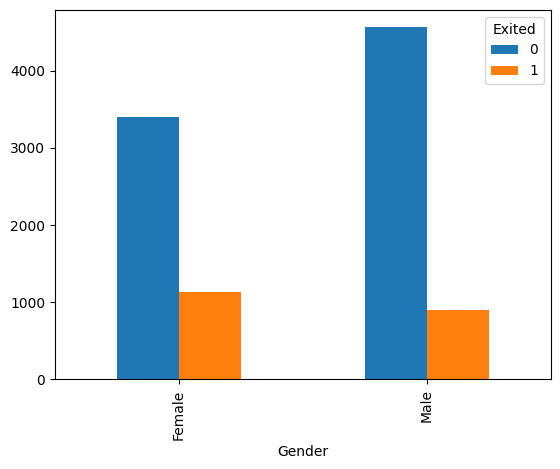

In [ ]:
gender = pd.crosstab(df.Gender, df.Exited)
gender.plot(kind='bar')
gender['prop'] = gender[1]/(gender[0]-gender[1])

In [ ]:
gender

Exited,0,1,prop
Gender,,,
Female,3404,1139,0.502870
Male,4559,898,0.245288


In [ ]:
print((df.Gender == 'Female').sum())

4543


In [ ]:
gen = (df.Gender=='Female')
gen.sum()

np.int64(4543)

In [ ]:
df.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


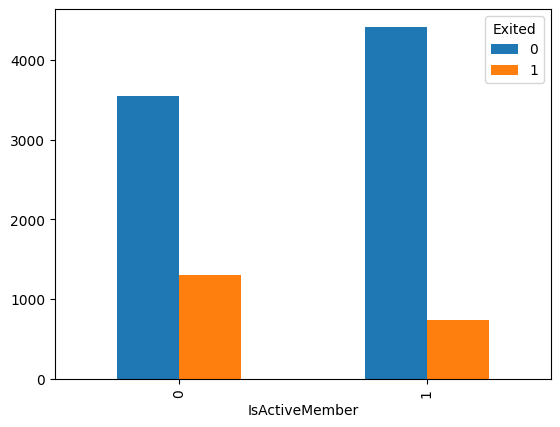

In [ ]:
IsActiveMember = pd.crosstab(df.IsActiveMember, df.Exited)
IsActiveMember.plot(kind='bar')
IsActiveMember['prop'] = IsActiveMember[1]/(IsActiveMember[0]-IsActiveMember[1])

In [ ]:
IsActiveMember

Exited,0,1,prop
IsActiveMember,,,
0,3547,1302,0.579955
1,4416,735,0.199674


In [ ]:
1302/(1302+3547)

0.26850897092183956

In [ ]:
735/(735+4416)

0.14269073966220153

In [ ]:
# skewness and kurtoisis
Formula for skewness
# sum((xi-xbar)**3)/((n-1)*sd**3)

In [ ]:
x1 = np.repeat([1,2,3,4,5,6,7,8,9,10],[5,10,15,20,400,20,15,10,5,2])
x2 = np.repeat([1,2,3,4,5,6,7,8,9,10],[20,25,25,30,35,30,25,25,20,20])
x3 = np.repeat([1,2,3,4,5,6,7,8,9],[2,5,10,20,30,20,10,5,2])

In [ ]:
scipy.stats.kurtosis(x2)

np.float64(-1.0233152049490384)

In [ ]:
scipy.stats.kurtosis(x3)

np.float64(0.03926687623208469)

(array([ 2.,  5., 10., 20.,  0., 30., 20., 10.,  5.,  2.]),
 array([1. , 1.8, 2.6, 3.4, 4.2, 5. , 5.8, 6.6, 7.4, 8.2, 9. ]),
 <BarContainer object of 10 artists>)

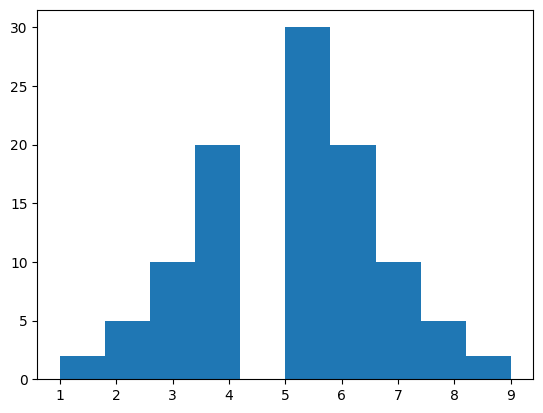

In [ ]:
plt.hist(x3)

In [ ]:
# formula for kurtosis
sum((xi-xbar)**4)/(n*sd**4) - 3